In [1]:
import pandas as pd

q = pd.read_csv("../results/kamervragen_annotated_q_v0.6.csv", sep="\t")
a = pd.read_csv("../results/kamervragen_annotated_a_v0.2.csv", sep="\t")

# Keep only annotation columns from answers file
a_ann = a[["src_id", "vraag_nr", "llm_label", "llm_confidence", "llm_reasoning"]]

df = q.rename(columns={
    "llm_label":      "q_label",
    "llm_confidence": "q_confidence",
    "llm_reasoning":  "q_reasoning",
}).merge(
    a_ann.rename(columns={
        "llm_label":      "a_label",
        "llm_confidence": "a_confidence",
        "llm_reasoning":  "a_reasoning",
    }),
    on=["src_id", "vraag_nr"],
    how="left",  # keep all questions; a_label NaN where answer was too short
)


In [2]:
ct = pd.crosstab(df["q_label"], df["a_label"], normalize=False)
print(ct)

a_label  ADV  DEFL  FEIT  OOR
q_label                      
?          0     1     1    0
ADV      145    65    22   25
AGN        4    15     6    2
CAU       20    76   159   59
FEIT      15   145   304   48
OOR       68   157   192  196


<Axes: xlabel='a_label', ylabel='q_label'>

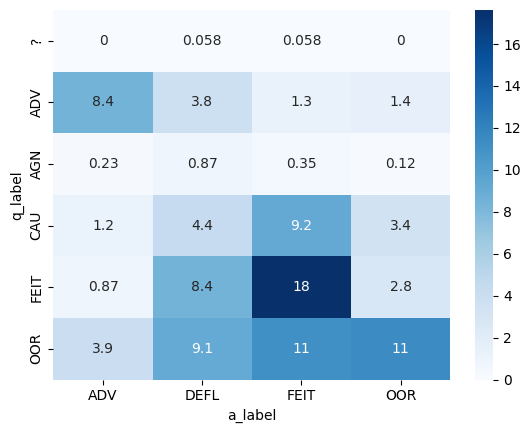

In [12]:
sns.heatmap(ct * 100, cmap='Blues', annot=True)

In [4]:
import seaborn as sns

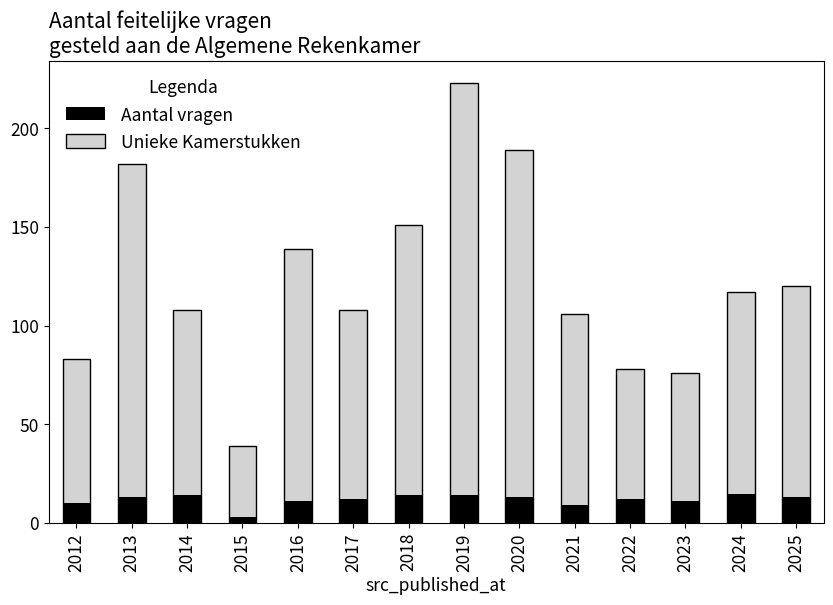

In [47]:
import matplotlib.pyplot as plt
import pandas as pd

# Set font before creating the figure
plt.rcParams['font.family'] = 'Source Sans Pro'
plt.rcParams['font.size'] = 14

# Create figure and axes
fig, ax = plt.subplots(figsize=(10,6))

# First bar plot: 'Aantal vragen'
pd.to_datetime(du.src_published_at).dt.year.value_counts().sort_index().plot(
    kind='bar', color='black', ax=ax, label='Aantal vragen', width=0.5
)

# Second bar plot: 'Unieke Kamerstukken' (light grey) on same ax
dat.groupby(pd.to_datetime(dat.src_published_at).dt.year).size().sort_index().plot(
    kind='bar', color='lightgrey', width=0.5, label='Unieke Kamerstukken',
    zorder=-1, edgecolor='black', ax=ax
)

# Titles and legend
ax.set_title("Aantal feitelijke vragen\ngesteld aan de Algemene Rekenkamer", loc='left')
ax.legend(title="Legenda", frameon=False, loc='upper left')

# Optional: save figure
# plt.savefig(FIGS / "n_vragen.png", dpi=500, bbox_inches='tight')
plt.show()

<Axes: xlabel='src_published_at'>

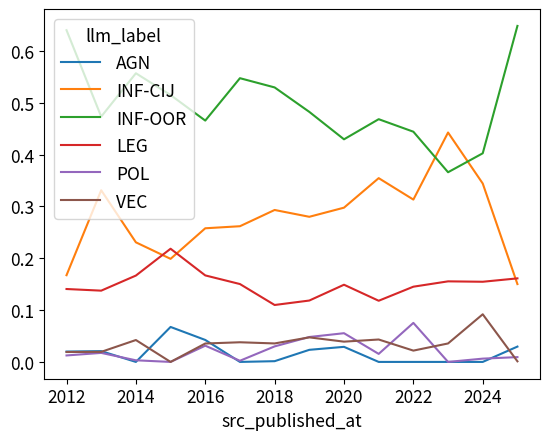

In [75]:
df.groupby(pd.to_datetime(df.src_published_at).dt.year). \
    llm_label. \
    value_counts(normalize=True). \
    unstack().fillna(0.0). \
    plot()
    # plot(kind='bar',stacked=True)

In [6]:
dfr = pd.read_csv('/home/rb/Documents/Code/Rekenkamer/results/kamervragen-metadata.csv', sep='\t')
dfs = pd.read_csv('/home/rb/Documents/Code/Rekenkamer/results/kamervragen-structured.csv', sep='\t')
dfv = pd.read_csv('/home/rb/Documents/Code/Rekenkamer/results/kamervragen-raw.csv', sep='\t')

In [59]:
dfr['actor'] = dfr.commissie.str.lower()

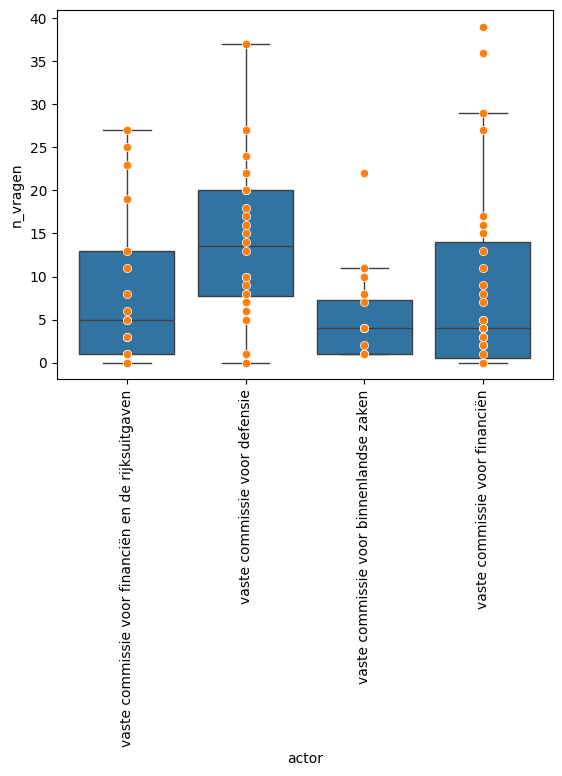

In [71]:
ax = sns.boxplot(data=dfr[dfr.actor.map(dfr.groupby('actor').size()) > 10], x='actor', y='n_vragen', showfliers=False)
sns.scatterplot(data=dfr[dfr.actor.map(dfr.groupby('actor').size()) > 10], x='actor', y='n_vragen', ax=ax, zorder=10)

ax.xaxis.set_tick_params(rotation=90)

In [46]:
import seaborn as sns

<Axes: >

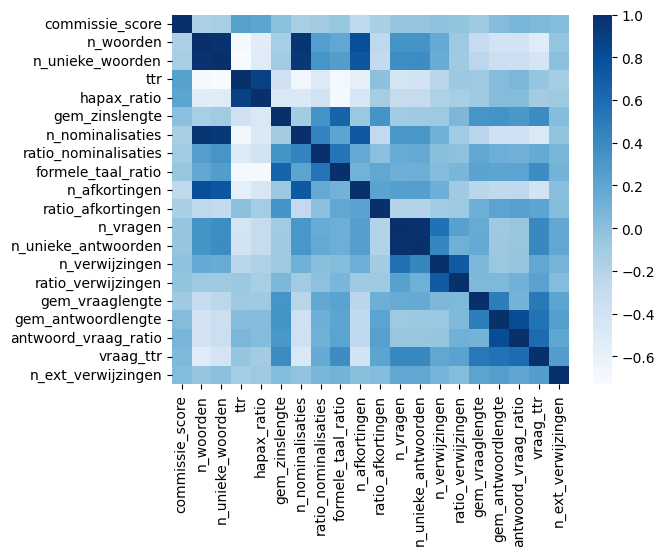

In [48]:
sns.heatmap(dfr.iloc[:,6:].corr(),cmap='Blues')

In [56]:
dfr.iloc[:,6:].corr()['formele_taal_ratio'].nlargest(15)

formele_taal_ratio      1.000000
gem_zinslengte          0.651579
ratio_nominalisaties    0.544501
vraag_ttr               0.384481
n_unieke_woorden        0.268027
gem_vraaglengte         0.226264
antwoord_vraag_ratio    0.221590
gem_antwoordlengte      0.207170
n_nominalisaties        0.204585
ratio_afkortingen       0.192378
n_woorden               0.187062
n_unieke_antwoorden     0.132176
n_vragen                0.126181
n_afkortingen           0.102941
n_ext_verwijzingen      0.094867
Name: formele_taal_ratio, dtype: float64

<Axes: xlabel='formele_taal_ratio', ylabel='ratio_nominalisaties'>

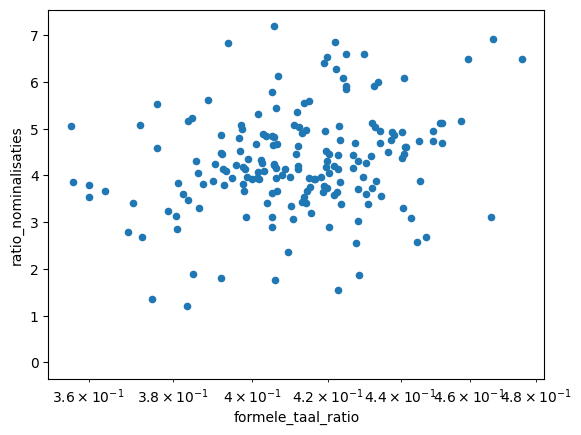

In [57]:
dfr.plot.scatter(x='formele_taal_ratio',y='ratio_nominalisaties', logx=True)

In [34]:
print(dfv.doc_content[2])

Algemene Rekenkamer . mm f ® Lange Voorhout 8 BEZORGEN Postbus 20015 2500 EA Den Haag T 070 - 342 43 44 F 070 - 342 41 30 Binnenhof 4 E  voorlichting@rekenkamer.nl 2513 AA DEN HAAG Ww www,rekenkamer.n! De voorzitter van de Tweede Kamer der Staten-Generaal vatum 3 mei 2012 setrerr Beantwoording Kamervragen bij rapport 'Prestaties in de strafrechtketen’ (Tweede Kamer, vergaderjaar 2011-2012, 33 173, nr. 2) Geachte mevrouw Verbeet, Hierbij bieden wij u de op 3 mei 2012 vastgestelde antwoorden aan op de door de commissies voor Veiligheid en Justitie en voor de Rijksuitgaven gestelde vragen over het rapport Prestaties in de strafrechtketen (Tweede Kamer, vergaderjaar 2011-2012, 33 173, nrs 1-2), Algemene Reke dr. Ellen M.A, van Schoten RA, secretaris UW KENMERK ONS KENMERK 12002781 R BIJLAGEN Antwoorden op rapport Prestaties in de strafrechtketen Antwoorden Algemene Rekenkamer op vragen over rapport Prestaties in de Strafrechtketen (Tweede Kamer, vergaderjaar 2011-2012, 33 173, ne@ 2) e Ant

In [39]:
dfr[dfr.n_vragen==0].shape

(23, 26)